# Warped Disk Geometry Demo

This notebook generates a simple geometric visualization of a warped disk using a prescribed radial tilt profile.

## What this notebook does
- defines a smooth warp profile $\beta(r)$,
- constructs the corresponding warped disk surface,
- renders a 3D view,
- shows a side-view schematic, and
- plots the inclination and warp-amplitude profiles.

## Notes
This is a geometric illustration rather than a hydrodynamic simulation. 


## Imports and plotting configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgb

plt.rcParams.update({"font.size": 16})


## Model definition

We prescribe a smooth tilt profile centered at `r_warp` with width `d_warp` and maximum inclination `beta_max`.
The disk is then constructed by tilting circular rings about the \(+y\)-axis.


In [2]:
# Disk / warp parameters
r_in, r_out = 0.2, 3.0
n_r, n_phi = 256, 64

H_over_R = 0.03
beta_max = np.deg2rad(25.0)
r_warp, d_warp = 1.5, 0.5


def beta_of_r(r):
    """Smooth radial inclination profile."""
    return 0.5 * beta_max * (1.0 + np.tanh((r - r_warp) / d_warp))


def build_warped_surface(r_in, r_out, n_r, n_phi):
    """Return coordinates and shading fields for a warped disk surface."""
    r = np.linspace(r_in, r_out, n_r)
    phi = np.linspace(0.0, 2.0 * np.pi, n_phi, endpoint=True)
    R, PHI = np.meshgrid(r, phi, indexing="ij")

    # Flat reference disk
    X0 = R * np.cos(PHI)
    Y0 = R * np.sin(PHI)
    Z0 = np.zeros_like(X0)

    # Warp by rotating each ring about +y
    B = beta_of_r(R)
    X = X0 * np.cos(B)
    Y = Y0
    Z = -X0 * np.sin(B)

    # Surface normals for simple Lambert-style shading
    dB_dr = np.gradient(B, r, axis=0)

    dX_dr = np.cos(PHI) * np.cos(B) - X0 * np.sin(B) * dB_dr
    dY_dr = np.sin(PHI)
    dZ_dr = -np.cos(PHI) * np.sin(B) - X0 * np.cos(B) * dB_dr

    dX_dphi = -R * np.sin(PHI) * np.cos(B)
    dY_dphi =  R * np.cos(PHI)
    dZ_dphi =  R * np.sin(PHI) * np.sin(B)

    nx = dY_dr * dZ_dphi - dZ_dr * dY_dphi
    ny = dZ_dr * dX_dphi - dX_dr * dZ_dphi
    nz = dX_dr * dY_dphi - dY_dr * dX_dphi

    nhat = np.stack([nx, ny, nz], axis=-1)
    nhat /= np.linalg.norm(nhat, axis=-1, keepdims=True) + 1e-12

    light_dir = np.array([0.7, 0.6, 0.35], dtype=float)
    light_dir /= np.linalg.norm(light_dir)

    lambert = 0.25 + 0.75 * np.clip(
        nhat[..., 0] * light_dir[0]
        + nhat[..., 1] * light_dir[1]
        + nhat[..., 2] * light_dir[2],
        0.0,
        1.0,
    )

    return r, phi, R, PHI, B, X, Y, Z, lambert


def plot_surface_with_shading(ax, X, Y, Z, lambert, base_color="C0", elev=35, azim=40):
    """Plot the warped surface with simple manual shading and a soft shadow plane."""
    rgb = np.array(to_rgb(base_color))
    lambert_face = lambert[:-1, :-1]

    facecolors = np.empty(lambert_face.shape + (4,), dtype=float)
    facecolors[..., :3] = lambert_face[..., None] * rgb
    facecolors[..., 3] = 1.0

    shadow_height = H_over_R * r_out
    ax.plot_surface(
        X, Y, Z - shadow_height,
        color=(0, 0, 0), alpha=0.5, shade=False,
        linewidth=0, antialiased=True, edgecolor="none",
    )

    ax.plot_surface(
        X, Y, Z,
        facecolors=facecolors, shade=False,
        linewidth=0.02, antialiased=True, edgecolor="w",
    )

    ax.view_init(elev=elev, azim=azim)
    ax.set_proj_type("persp")
    ax.set_box_aspect((1, 1, 0.5))
    ax.grid(False)
    ax.set_xlabel("$x$", labelpad=6)
    ax.set_ylabel("$y$", labelpad=6)
    ax.text(3.0, -3.6, 1.3, "$z$", ha="left", va="bottom", fontsize=14)


r, phi, R, PHI, B, X, Y, Z, lambert = build_warped_surface(r_in, r_out, n_r, n_phi)


## 3D view of the warped disk

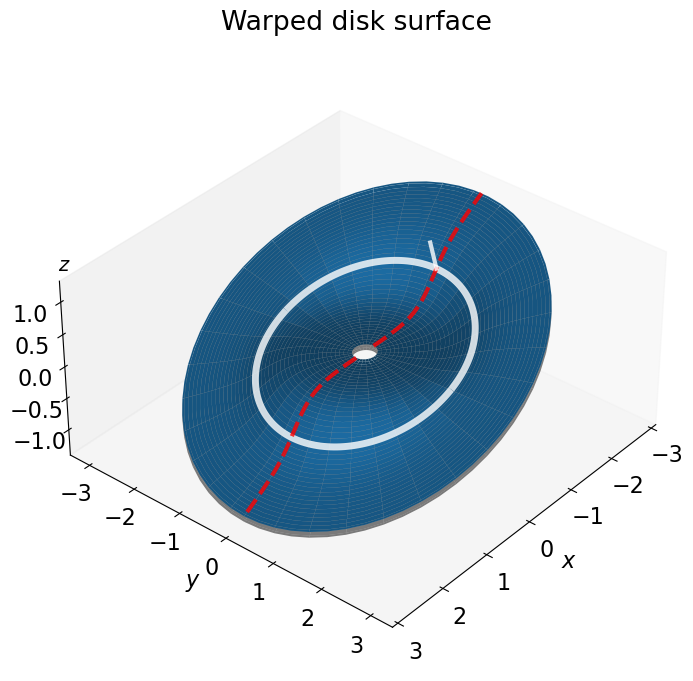

In [9]:
fig, ax = plt.subplots(
    1, 1, figsize=(8, 8), subplot_kw={"projection": "3d"}
)

plot_surface_with_shading(ax, X, Y, Z, lambert, base_color="C0", elev=35, azim=40)

# Highlight the x-z cross-section at y = 0
cross_kw = {"c": "r", "lw": 3, "ls": "--", "alpha": 0.8, "zorder": 10}
r_line = np.linspace(r_in, r_out, 101)
x_line = -r_line * np.cos(beta_of_r(r_line))
z_line =  r_line * np.sin(beta_of_r(r_line))

ax.plot(+x_line, np.zeros_like(r_line), +z_line, **cross_kw)
ax.plot(-x_line, np.zeros_like(r_line), -z_line, **cross_kw)

# Mark a representative local angular-momentum direction
r_probe = 1.75
x_probe = -r_probe * np.cos(beta_of_r(r_probe))
y_probe = 0.0
z_probe =  r_probe * np.sin(beta_of_r(r_probe))

lhat = np.array([
    np.sin(beta_of_r(r_probe)),
    0.0,
    np.cos(beta_of_r(r_probe)),
])

arrow_length = 0.5
x_tip = x_probe + arrow_length * lhat[0]
y_tip = y_probe + arrow_length * lhat[1]
z_tip = z_probe + arrow_length * lhat[2]

ax.plot([x_probe, x_tip], [y_probe, y_tip], [z_probe, z_tip],
        c="w", lw=3, alpha=0.8, zorder=10)

# Mark a ring at the probe radius
ring_kw = {"c": "w", "lw": 5, "ls": "-", "alpha": 0.8, "zorder": 8}
phi_ring_1 = np.linspace(0.5 * np.pi, 1.5 * np.pi, 101)
phi_ring_2 = np.linspace(-0.5 * np.pi, 0.5 * np.pi, 101)[2:-2]

for phi_ring in (phi_ring_1, phi_ring_2):
    x_ring = -r_probe * np.cos(beta_of_r(r_probe)) * np.cos(phi_ring)
    y_ring =  r_probe * np.sin(phi_ring)
    z_ring =  r_probe * np.sin(beta_of_r(r_probe)) * np.cos(phi_ring)
    ax.plot(x_ring, y_ring, z_ring, **ring_kw)

ax.set_title("Warped disk surface", pad=18)
plt.show()


## Side-view schematic

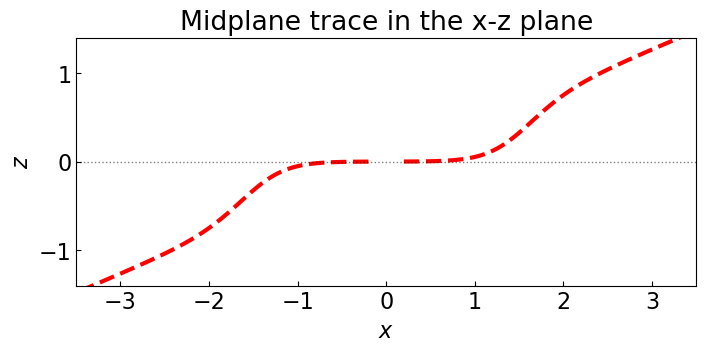

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

r_plot_max = 3.5
R0 = np.linspace(0.2, r_plot_max, 101)

z_mid = R0 * np.sin(beta_of_r(R0))

ax.plot(+R0, +z_mid, c="r", ls="--", lw=3)
ax.plot(-R0, -z_mid, c="r", ls="--", lw=3)

ax.axhline(0.0, lw=1, ls=":", c="k", alpha=0.5)
ax.set_xlim([-r_plot_max, r_plot_max])
ax.set_ylim([-0.4 * r_plot_max, 0.4 * r_plot_max])
ax.set_aspect("equal", adjustable="box")
ax.tick_params(which="both", direction="in")
ax.set_xlabel("$x$")
ax.set_ylabel("$z$")
ax.set_title("Midplane trace in the x-z plane")
plt.show()


## Inclination and warp profiles

Here we plot the prescribed inclination profile \(\beta(r)\) and the corresponding warp amplitude
\(|\psi| = r \, d\beta/dr\) for this simple untwisted example.


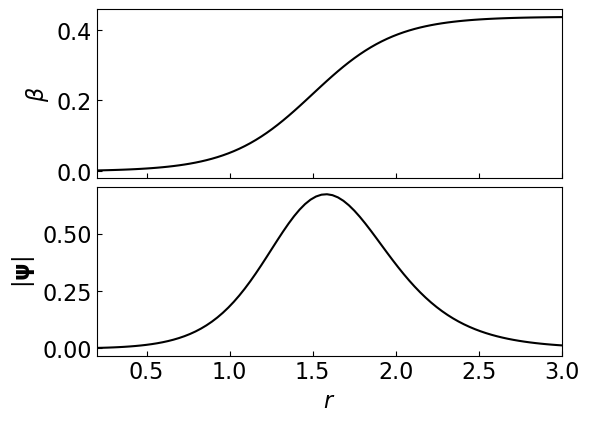

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True)
fig.subplots_adjust(hspace=0.05)

R0 = np.linspace(0.2, 3.5, 101)
beta_profile = beta_of_r(R0)
psi_profile = R0 * np.gradient(beta_profile, R0)

axes[0].plot(R0, beta_profile, c="k")
axes[1].plot(R0, psi_profile, c="k")

axes[0].set_ylabel(r"$\beta$")
axes[1].set_ylabel(r"$|\mathbf{\psi}|$")
axes[1].set_xlabel(r"$r$")
axes[0].set_xlim([0.2, 3.0])

for ax in axes:
    ax.tick_params(which="both", direction="in")

plt.show()
